In [16]:
import numpy as np

def omp(y, D, sparsity):
    """
    Orthogonal Matching Pursuit
    
    y: signal (n,)
    D: dictionary (n, K)
    sparsity: number of atoms to select
    
    returns sparse coefficient vector x
    """
    
    n, K = D.shape
    residual = y.copy()
    
    active_set = []
    x = np.zeros(K)
    
    for _ in range(sparsity):
        
        # Step 1: correlations
        correlations = D.T @ residual
        
        # Step 2: pick best atom
        idx = np.argmax(np.abs(correlations))
        active_set.append(idx)
        
        # Step 3: solve least squares on active atoms
        D_active = D[:, active_set]
        x_active, *_ = np.linalg.lstsq(D_active, y, rcond=None)
        
        # Step 4: update residual
        residual = y - D_active @ x_active
        
    # place active coefficients into full vector
    for i, idx in enumerate(active_set):
        x[idx] = x_active[i]
        
    return x

In [3]:

n = 128
K = 256

# dictionary
D = np.random.randn(n, K)
D = D / np.linalg.norm(D, axis=0)

# sparse ground truth
x_true = np.zeros(K)
x_true[np.random.choice(K, 5, replace=False)] = np.random.randn(5)

# signal
y = D @ x_true

# run OMP
x_est = omp(y, D, sparsity=5)

print("True nonzeros:", np.where(x_true != 0)[0])
print("Recovered:", np.where(np.abs(x_est) > 1e-3)[0])

True nonzeros: [ 23  81 185 199 214]
Recovered: [ 23  81 185 199 214]


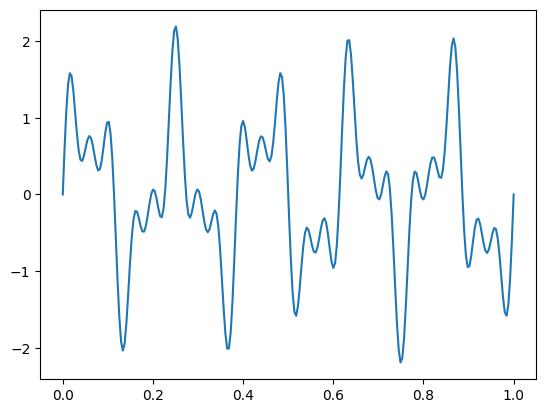

In [18]:
import matplotlib.pyplot as plt

n = 256
t = np.linspace(0, 1, n)

# signal composed of a few sinusoids
y = (
    1.0*np.sin(2*np.pi*5*t) +
    0.7*np.sin(2*np.pi*13*t) +
    0.5*np.sin(2*np.pi*21*t)
)
plt.plot(t, y)
plt.show()

In [ ]:
K = 128
D = np.zeros((n, K))

for k in range(K):
    D[:, k] = np.cos(2*np.pi*k*t)

# normalize atoms
D = D / np.linalg.norm(D, axis=0)
print(D)

[[        nan  0.          0.         ...  0.          0.
   0.        ]
 [        nan  0.00216916  0.00433701 ...  0.00650225  0.00433701
   0.00216916]
 [        nan  0.00433701  0.00866357 ... -0.01296926 -0.00866357
  -0.00433701]
 ...
 [        nan -0.00650225 -0.01296926 ... -0.019366   -0.01296926
  -0.00650225]
 [        nan -0.00433701 -0.00866357 ...  0.01296926  0.00866357
   0.00433701]
 [        nan -0.00216916 -0.00433701 ... -0.00650225 -0.00433701
  -0.00216916]]


/tmp/ipykernel_23138/3170479939.py:8: RuntimeWarning: invalid value encountered in divide
  D = D / np.linalg.norm(D, axis=0)


In [23]:
from sklearn.linear_model import OrthogonalMatchingPursuit

omp = OrthogonalMatchingPursuit(n_nonzero_coefs=6)
omp.fit(D, y)

x = omp.coef_

y_hat = D @ x

# plt.plot(y)
plt.plot(y_hat)
plt.show()

ValueError: Input X contains NaN.
OrthogonalMatchingPursuit does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values